---
title: "Deep Learning Methods for Solving Dynamic Economic Models"
author:
  - name: "Lecturer: Bo Li"
    affiliation: "School of Economics, Peking University"
    email: "libo.econ@pku.edu.cn"
  - name: "TA: Chen Gao"
    affiliation: "National School of Development, Peking University"
    email: "chengao0716@gmail.com"
date: today
format:
  revealjs:
    embed-resources: true
    smaller: true
    echo: true
    urlcolor: orange
    toc: true
    toc-depth: 1
    transition: fade
    code-block-height: 400px
    slide-number: c/t
    show-slide-number: all

  pdf:
    toc: true
    toc-depth: 1
    monofont: "Fira Code"
    mainfont: "Libertinus Serif"
    mathfont: "Libertinus Math"
    sansfont: "Fira Sans"
    urlcolor: orange
    citecolor: blue
    linkcolor: red
    number-sections: true
jupyter: python3
keep-ipynb: true
bibliography: DLMethods.bib
execute:
    eval: true
---

# Introduction

## Where We Are

-  The **Krusell-Smith** algorithm [@krusell_smith_1998] replaced the infinite-dimensional distribution $\mu$ with a forecasting rule
  $$
  \log K' = a_{0,z} + a_{1,z} \log K.
  $$
- That works because *approximate aggregation* happens to hold in many models.
- **But it has clear limits**:
  - The forecasting rule is a hand-picked low-dimensional summary; adding moments is mechanical and ad hoc.
  - It does not scale beyond models where the wealth distribution barely matters for aggregates.
  - It relies on grid-based policy iteration for the household problem.

---

## The Curse of Dimensionality

- Grid-based methods scale as $G^d$:
    - $G$ grid points per dimension, $d$ state dimensions.
    - 5 states with 50 grid points each $\Rightarrow$ $3\times 10^8$ grid points.
- Many modern macro models live well beyond this limit:
    - Heterogeneous agents with rich idiosyncratic risk
    - Multiple aggregate shocks
    - Occasionally binding constraints
    - Portfolio choice over many assets
- We need a different family of approximators.

## A Different Idea: Use Neural Networks

- A neural network is a flexible *parametric* family
  $$
  \psi(x; \theta),
  $$
  whose number of parameters grows **linearly** with input dimension.
- @cybenko_1989 and @hornik_stinchcombe_white_1989: a single-hidden-layer network with enough units can approximate any continuous function on a compact set (*universal approximation*).
- Modern deep networks: just stack more layers and let stochastic optimization fit $\theta$.

## The AI-Economics Analogy

::: {.callout-note}
From @maliar_maliar_winant_2021:

An AI agent has a **goal**, **perceives an environment**, and **takes actions** to achieve its goal.
This is exactly an **economic agent**:

- goal = maximize utility / minimize residual
- environment = state variables
- action = policy / decision rule
:::

- The machinery built for training AI systems (autodiff, stochastic gradient descent, GPUs) was designed for **exactly this kind of object**.
- We just have to recognize that an economic decision rule *is* a function approximation problem.

## What This Lecture Covers

::::{.columns}
:::{.column width="50%"}
**Plan**

1. ML basics (NN, loss, SGD, autodiff)
2. A toy consumption-saving model
3. Three loss formulations
4. The all-in-one (AiO) expectation operator
5. JAX implementation, end-to-end
6. Scaling up to KS
:::
:::{.column width="50%"}
**Goal**

- Treat the **decision rule itself** as the object we parameterize and train.
- Replace fixed grids with **random samples** from the state space.
- Replace Bellman/Euler iteration with **gradient descent on a loss function**.
- Make every component **automatically differentiable** so JAX does the bookkeeping.
:::
::::


# ML Basics

## Neural Network as a Function Family

- A neural network is simply a parametric function $\psi(x; \theta)$ that maps inputs $x \in \mathbb{R}^{n_x}$ to outputs $\psi \in \mathbb{R}^{n_o}$.
- In our setting:
  - $x$ = state variables $(w, y, K, \dots)$
  - $\psi$ = decision rule (consumption share, savings, etc.)
- What distinguishes a NN from a polynomial:
    - It is **nonlinear in its parameters** $\theta$.
    - It scales gracefully with input dimension.
    - It can fit kinks, discontinuities, and switching behavior.

## Multilayer Perceptron (MLP)

- A *multilayer perceptron* (MLP) with $L$ hidden layers is the composition

$$
\psi(x;\theta) \;=\; W_L \, h_{L-1} + b_L,
\qquad
h_\ell \;=\; \sigma\!\left( W_\ell h_{\ell-1} + b_\ell \right),
\quad h_0 = x.
$$

- Parameters: $\theta = \{W_\ell, b_\ell\}_{\ell=1}^L$ — linear maps plus biases.
- $\sigma(\cdot)$ is a **nonlinear activation** (ReLU, tanh, sigmoid).
- Without $\sigma$, the network collapses to a single linear map.

## Activation Functions

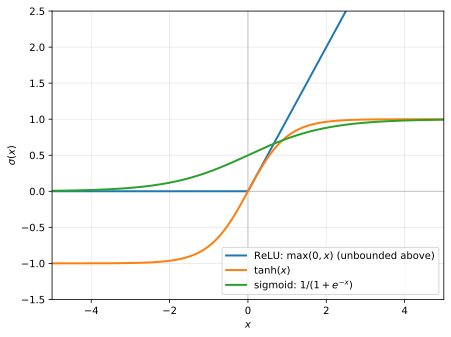

In [16]:
# | echo: false
import numpy as np
import matplotlib.pyplot as plt

%config InlineBackend.figure_format = 'svg'

x = np.linspace(-5, 5, 400)
relu = np.maximum(0, x)
tanh = np.tanh(x)
sigmoid = 1 / (1 + np.exp(-x))

fig, ax = plt.subplots()
ax.axhline(0, color="gray", linewidth=0.8, alpha=0.5)
ax.axvline(0, color="gray", linewidth=0.8, alpha=0.5)
ax.plot(x, relu, linewidth=2, label=r"ReLU: $\max(0,x)$ (unbounded above)")
ax.plot(x, tanh, linewidth=2, label=r"$\tanh(x)$")
ax.plot(x, sigmoid, linewidth=2, label=r"sigmoid: $1/(1+e^{-x})$")
ax.set_ylim(-1.5, 2.5)
ax.set_xlim(-5, 5)
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$\sigma(x)$")
ax.grid(alpha=0.3)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

- *Sigmoid* and *tanh* saturate at the tails $\Rightarrow$ vanishing gradients in deep networks.
- *ReLU* is piecewise linear and unbounded above $\Rightarrow$ robust gradients, but suffers from "dying ReLU" when inputs stay negative.
- Default choice in modern deep RL / economics applications: **ReLU** (or variants like GELU, Swish).

## Training = Optimization

Given a loss $\Xi(\theta)$, the parameters are updated by stochastic gradient descent (SGD):

$$
\theta \leftarrow \theta - \lambda \, \nabla_\theta \Xi(\theta)
$$

- $\lambda$ = learning rate.
- **Why "stochastic"?** The true loss is typically an *expectation* over data points or shocks,
$$
\Xi(\theta) \;=\; \mathbb{E}_{\omega}\!\left[\ell(\theta;\omega)\right],
$$
which is infeasible to evaluate exactly. At each step we draw a Monte Carlo minibatch $\{\omega_i\}_{i=1}^B$ and replace $\nabla_\theta \Xi$ with its sample-average estimate
$$
\widehat{\nabla_\theta \Xi}(\theta) \;=\; \tfrac{1}{B}\sum_{i=1}^{B} \nabla_\theta \ell(\theta;\omega_i).
$$
This estimator is **unbiased** but noisy — and the noise actually *helps*: it lets SGD escape saddle points and shallow local minima that full-batch GD gets stuck in.

## Adam: Adaptive Moments

Vanilla SGD uses a *single* learning rate $\lambda$ for every parameter and ignores gradient history. In high-dimensional, ill-conditioned losses (which deep networks always have), some directions need tiny steps while others need large ones.

**Adam** [@kingma_ba_2014_adam] fixes this by tracking two exponential moving averages (EMAs) of the gradient $g_t = \nabla_\theta \Xi(\theta_t)$:

$$
m_t \;=\; \beta_1 m_{t-1} + (1-\beta_1)\, g_t,
\qquad
v_t \;=\; \beta_2 v_{t-1} + (1-\beta_2)\, g_t^{\,2}.
$$

- $m_t$ — running estimate of the **mean** gradient (momentum).
- $v_t$ — running estimate of the **squared** gradient (per-parameter scale).

After a small bias correction (omitted here), the parameter update is

$$
\theta \;\leftarrow\; \theta \;-\; \lambda\, \frac{\hat m_t}{\sqrt{\hat v_t} + \epsilon}.
$$

---

**Intuition**: each parameter gets its *own* effective learning rate $\lambda / \sqrt{\hat v_t}$ — small when its gradients are persistently large or noisy, large when they are small. 

Adam is the *default* in JAX/`optax` because it works robustly with almost no tuning: $\beta_1 {=} 0.9$, $\beta_2 {=} 0.999$, $\lambda {=} 10^{-3}$ are the canonical defaults.

:::{.callout-note}
### The big question:
How do we get  $\nabla_\theta \Xi(\theta)$ when $\Xi$  contains deep network compositions, simulations, conditional expectations?
:::

## Automatic Differentiation

- **Autodiff** computes $\nabla_\theta \Xi$ exactly (up to floating-point error), by tracking every elementary operation in $\Xi(\theta)$ and applying the chain rule.
- This is *not* numerical differentiation, *not* symbolic differentiation.
- JAX exposes it as a single function:

```python
import jax
grad_fn = jax.grad(loss_fn)   # returns a function that computes the gradient
g = grad_fn(theta)            # exact gradient at theta
```

- Combined with `jax.jit` (compile) and `jax.vmap` (vectorize), autodiff turns a Python expression for $\Xi(\theta)$ into a fast gradient routine.

## Autodiff in Action: CRRA Example

Take the **CRRA utility** $u(c) = c^{1-\gamma}/(1-\gamma)$, with $\gamma = 2$. The analytical derivative is $u'(c) = c^{-\gamma}$. We use `jax.grad` to get it without writing the formula:

In [17]:
import jax
import jax.numpy as jnp

jax.config.update("jax_enable_x64", True)

gamma = 2.0


def u(c):
    return c ** (1 - gamma) / (1 - gamma)


du = jax.grad(u)  # autodiff: returns a *function*
du_vec = jax.vmap(du)  # vectorize over an array of c values

print(f"JAX   u'(2.0) = {du(2.0):.6f}")
print(f"True  2.0**(-gamma) = {2.0 ** (-gamma):.6f}")

JAX   u'(2.0) = 0.250000
True  2.0**(-gamma) = 0.250000


---

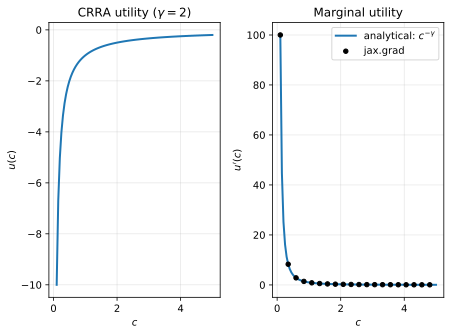

In [18]:
# | echo: false

c = jnp.linspace(0.1, 5.0, 100)
fig, axes = plt.subplots(1, 2)

axes[0].plot(c, u(c), linewidth=2)
axes[0].set_xlabel(r"$c$")
axes[0].set_ylabel(r"$u(c)$")
axes[0].set_title(r"CRRA utility ($\gamma = 2$)")
axes[0].grid(alpha=0.3)

axes[1].plot(c, c ** (-gamma), linewidth=2, label=r"analytical: $c^{-\gamma}$")
axes[1].scatter(c[::5], du_vec(c)[::5], color="black", s=20, zorder=3, label="jax.grad")
axes[1].set_xlabel(r"$c$")
axes[1].set_ylabel(r"$u'(c)$")
axes[1].set_title("Marginal utility")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

- `jax.grad(u)` returns a **function**, not a value — you call it at any $c$ to get the gradient.
- The black dots and the analytical line coincide: autodiff is *exact*, not a finite-difference approximation.
- The same pattern scales: `jax.grad(loss_fn)` gives $\nabla_\theta \Xi$ for a loss with thousands of parameters $\theta$.

## A Minimal Demo: Fitting a Kinked Policy

We will use NNs to learn unknown decision rules. Before doing that on a real model, let's check that a small NN can fit a function that **looks like** an economic decision rule — including a kink.

Target function:
$$
c^\star(w) \;=\; \min\!\left( w, \; 0.3 w + 0.4 \right),
$$
i.e., consume everything when $w$ is small (borrowing constraint binds) and consume a fixed fraction plus a constant otherwise.

---

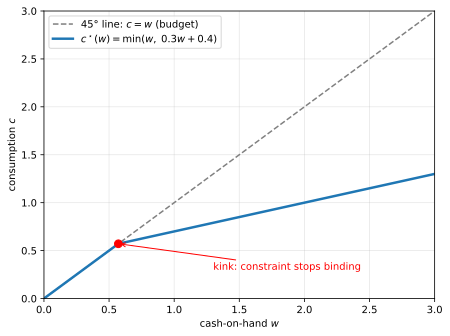

In [19]:
import numpy as np
import optax
import matplotlib.pyplot as plt
from typing import NamedTuple


def true_policy(w):
    return jnp.minimum(w, 0.3 * w + 0.4)


w = jnp.linspace(0, 3, 100)
w_kink = 4.0 / 7.0  # where w == 0.3*w + 0.4

fig, ax = plt.subplots()
ax.plot(
    w,
    w,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label=r"45° line: $c = w$ (budget)",
)
ax.plot(
    w,
    true_policy(w),
    color="C0",
    linewidth=2.5,
    label=r"$c^\star(w) = \min(w,\; 0.3w + 0.4)$",
)
ax.scatter([w_kink], [w_kink], color="red", s=60, zorder=5)
ax.annotate(
    "kink: constraint stops binding",
    xy=(w_kink, w_kink),
    xytext=(1.3, 0.3),
    arrowprops=dict(arrowstyle="->", color="red", lw=1),
    fontsize=10,
    color="red",
)
ax.set_xlabel(r"cash-on-hand $w$")
ax.set_ylabel(r"consumption $c$")
plt.xlim(0, 3)
plt.ylim(0, 3)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## Building an MLP From Scratch

We define the MLP using pure JAX. The point is to *show what is inside* — no framework magic.

In [20]:
def init_mlp(key, layer_sizes):
    """He-uniform initialization for an MLP — returns a list of (W, b) tuples,
    one per layer. `layer_sizes` lists units per layer, e.g. [1, 32, 32, 1].
    He init is the standard companion to ReLU-family activations
    (ReLU, GELU, Swish); Glorot is for tanh/sigmoid."""
    # JAX RNGs are stateless: split the master key into one subkey per layer
    # so each weight draw is independent and reproducible.
    keys = jax.random.split(key, len(layer_sizes) - 1)
    return [
        (
            # He-uniform bound sqrt(6/fan_in). The intuition: ReLU zeroes out
            # roughly half its inputs, so to keep activation variance constant
            # across layers we need a *larger* spread than Glorot's sqrt(6/(m+n))
            # would give. Using only fan_in (not fan_in+fan_out) compensates.
            jax.random.uniform(
                k,
                (m, n),  # weight shape: (fan_in, fan_out)
                minval=-jnp.sqrt(6.0 / m),
                maxval=jnp.sqrt(6.0 / m),
            ),
            jnp.zeros((n,)),  # bias starts at 0 (standard)
        )
        # zip adjacent sizes: (in_0, out_0), (in_1, out_1), ...
        for k, m, n in zip(keys, layer_sizes[:-1], layer_sizes[1:])
    ]


def mlp(params, x):
    """Forward pass: GELU on hidden layers, linear output.

    GELU is a smooth variant of ReLU. Same training benefits (non-saturating
    gradients) but C^infty, so the network's output is smooth in x — important
    when the target policy is itself smooth (e.g. CRRA Euler).
    """
    # Python unpacking: peel off the last layer (linear output head) from the rest.
    *hidden, (W_out, b_out) = params
    # Hidden layers: affine map then nonlinearity, x ← GELU(x W + b).
    for W, b in hidden:
        x = jax.nn.gelu(x @ W + b)
    # Output layer is linear (no squashing) — appropriate for regression-style
    # targets like a consumption policy that can take any real value.
    return x @ W_out + b_out

::: {.callout-tip}
Each layer is just a matrix multiply + bias + nonlinearity. An MLP is a deeply nested function — exactly the kind of thing autodiff handles trivially.
:::

## MLP Architecture: `[1, 32, 32, 1]`

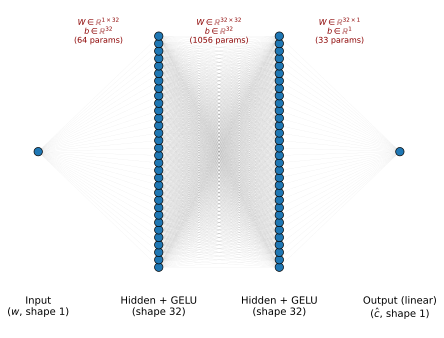

In [21]:
# | echo: false
layer_sizes = [1, 32, 32, 1]
activation_label = "GELU"

fig, ax = plt.subplots()
n_layers = len(layer_sizes)
xs = np.linspace(0.0, 1.0, n_layers)


def layer_ys(n):
    return np.array([0.0]) if n == 1 else np.linspace(-1.0, 1.0, n)


# --- draw all-to-all connections (faint) ---
for i in range(n_layers - 1):
    ys_l, ys_r = layer_ys(layer_sizes[i]), layer_ys(layer_sizes[i + 1])
    for yl in ys_l:
        for yr in ys_r:
            ax.plot(
                [xs[i], xs[i + 1]],
                [yl, yr],
                color="gray",
                linewidth=0.15,
                alpha=0.25,
                zorder=1,
            )

# --- draw neurons ---
for i, n in enumerate(layer_sizes):
    ax.scatter(
        [xs[i]] * n,
        layer_ys(n),
        s=70,
        color="C0",
        edgecolor="black",
        linewidth=0.7,
        zorder=3,
    )

# --- labels under each layer ---
labels = [f"Input\n($w$, shape {layer_sizes[0]})"]
for n in layer_sizes[1:-1]:
    labels.append(f"Hidden + {activation_label}\n(shape {n})")
labels.append(f"Output (linear)\n($\\hat c$, shape {layer_sizes[-1]})")
for x, label in zip(xs, labels):
    ax.text(x, -1.25, label, ha="center", va="top", fontsize=10)

# --- per-layer parameter counts as annotations between columns ---
for i in range(n_layers - 1):
    m, n = layer_sizes[i], layer_sizes[i + 1]
    ax.text(
        (xs[i] + xs[i + 1]) / 2,
        1.15,
        f"$W \\in \\mathbb{{R}}^{{{m}\\times{n}}}$\n$b \\in \\mathbb{{R}}^{{{n}}}$\n({m * n + n} params)",
        ha="center",
        va="top",
        fontsize=8,
        color="darkred",
    )

ax.set_xlim(-0.08, 1.08)
ax.set_ylim(-1.55, 1.25)
ax.axis("off")
plt.tight_layout()
plt.show()

- Total trainable parameters: $1{\cdot}32 + 32 + 32{\cdot}32 + 32 + 32{\cdot}1 + 1 = \mathbf{1{,}153}$.
- The 32×32 hidden block dominates — adding *width* (more units per layer) grows parameters quadratically; adding *depth* grows them linearly.

## MLP at Initialization

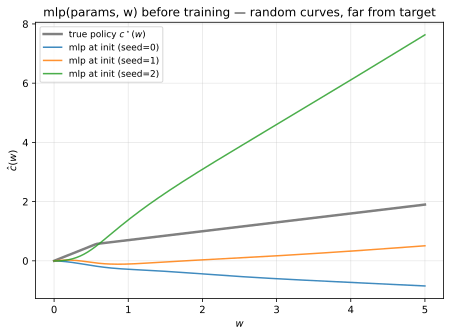

In [22]:
# | echo: false
layer_sizes = [1, 32, 32, 1]

fig, axes = plt.subplots()

# --- what mlp computes before training ---
w_grid = jnp.linspace(0, 5, 200).reshape(-1, 1)
w_flat = np.asarray(w_grid).ravel()

axes.plot(
    w_flat,
    np.asarray(true_policy(w_grid.ravel())),
    color="gray",
    linewidth=2.5,
    label=r"true policy $c^\star(w)$",
)
for seed in (0, 1, 2):
    p = init_mlp(jax.random.PRNGKey(seed), layer_sizes)
    axes.plot(
        w_flat,
        np.asarray(mlp(p, w_grid).ravel()),
        linewidth=1.5,
        alpha=0.85,
        label=f"mlp at init (seed={seed})",
    )
axes.set_title("mlp(params, w) before training — random curves, far from target")
axes.set_xlabel(r"$w$")
axes.set_ylabel(r"$\hat c(w)$")
axes.legend(loc="upper left", fontsize=9)
axes.grid(alpha=0.3)

plt.tight_layout()
plt.show()

- An untrained MLP is a *random function* of $w$. Different RNG seeds give different starting curves; none of them look like the true policy. **Training** is what turns one of these random wiggles into $c^\star$.

## Training the MLP

In [23]:
# --- Reproducible RNG and network ---
key = jax.random.PRNGKey(0)  # deterministic seed
params = init_mlp(
    key, [1, 32, 32, 32, 1]
)  # 3 hidden layers x 32 units; scalar in -> scalar out

# --- Training data: 1024 cash-on-hand draws uniform on [0, 3], targets = true policy ---
key, subkey = jax.random.split(key)  # fresh subkey so data draw is independent of init
w_train = jax.random.uniform(subkey, (1024, 1), minval=0.0, maxval=3.0)
c_train = true_policy(w_train)


# --- Loss: mean-squared error between MLP prediction and the true policy ---
def loss_fn(params, w, c):
    return jnp.mean((mlp(params, w) - c) ** 2)


# --- Optimizer: Adam with default beta_1=0.9, beta_2=0.999, learning rate 1e-3 ---
optimizer = optax.adam(1e-3)
opt_state = optimizer.init(
    params
)  # holds the per-parameter (m_t, v_t) moment estimates


# --- One training step, jit-compiled (huge speedup since we run it 3000 times) ---
@jax.jit
def train_step(params, opt_state, w, c):
    # value_and_grad returns (loss, grad_params loss) in a single autodiff pass —
    # cheaper than computing the loss and the gradient separately.
    loss, grads = jax.value_and_grad(loss_fn)(params, w, c)
    # Adam turns the raw gradient into a parameter update using its m_t, v_t state.
    updates, opt_state = optimizer.update(grads, opt_state)
    # Applies params <- params + updates (Adam already baked in the minus sign).
    return optax.apply_updates(params, updates), opt_state, loss

---

In [24]:
loss_history = []
for step in range(3000):
    params, opt_state, loss = train_step(params, opt_state, w_train, c_train)
    loss_history.append(float(loss))

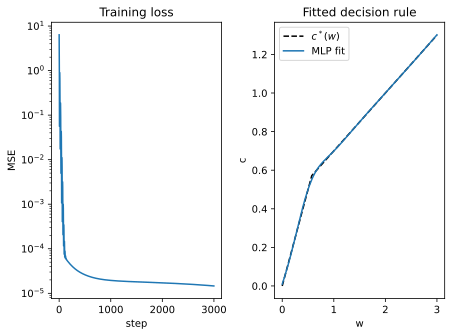

In [25]:
fig, axes = plt.subplots(1, 2)

axes[0].semilogy(loss_history)
axes[0].set_title("Training loss")
axes[0].set_xlabel("step")
axes[0].set_ylabel("MSE")

w_plot = jnp.linspace(0.0, 3.0, 200)[:, None]
axes[1].plot(w_plot, true_policy(w_plot), "k--", label=r"$c^*(w)$")
axes[1].plot(w_plot, mlp(params, w_plot), label="MLP fit")
axes[1].set_title("Fitted decision rule")
axes[1].set_xlabel("w")
axes[1].set_ylabel("c")
axes[1].legend()
plt.tight_layout()
plt.show()

## What We Just Learned

- A NN is a function approximator.
- Training reduces to: write a loss, ask JAX for its gradient, step.
- The kink is recovered cleanly — exactly what we need to handle borrowing constraints later.

::: {.callout-warning}
This was **supervised** learning: we had `c_target = c^*(w)` ready-made.
In economic models we never have the optimal policy as a "label."
The whole trick is to **construct the loss from the model's equilibrium conditions** — Euler equation, Bellman equation, or lifetime utility.
That is what the rest of the lecture is about.
:::


# The Toy Model

## Setup: A Cash-on-Hand Consumption-Saving Problem

Following [@maliar_maliar_winant_2021], consider a single agent who chooses consumption and saving:

$$
\max_{\{c_t, w_{t+1}\}_{t=0}^\infty} \;
\mathbb{E}_0 \!\left[\, \sum_{t=0}^\infty \beta^t \, u(c_t) \right]
$$

subject to

$$
\begin{aligned}
w_{t+1} &= \bar{r} \, (w_t - c_t) + \exp(y_{t+1}), \\
0 \le c_t &\le w_t, \\
y_{t+1} &= \rho \, y_t + \sigma \, \varepsilon_{t+1}, \qquad \varepsilon_{t+1} \sim \mathcal{N}(0, 1).
\end{aligned}
$$

- $w_t$ : beginning-of-period **cash-on-hand**, $y_t$ : log productivity / log income shock (AR(1))
- $\bar{r}$ : gross return on savings, with $\bar{r} \beta < 1$, $u(c) = \dfrac{c^{1-\gamma} - 1}{1 - \gamma}$, CRRA

## State Space and Decision Rule

- The state vector is $s = (y, w) \in \mathbb{R}^2$.
- The unknown is the time-invariant decision rule
  $$
  c = \psi(y, w; \theta).
  $$
- For numerical convenience we parameterize the **consumption share**
  $$
  \zeta(y, w; \theta) \equiv \frac{c}{w} \in [0, 1].
  $$
- The output of a **sigmoid-capped** NN gives $\zeta \in (0,1)$ by construction.

## The Borrowing Constraint and the Euler Equation

- Define savings $a \equiv w - c$. The constraint is $a \ge 0$.
- The Lagrangian gives Kuhn-Tucker conditions:
$$
a \ge 0, \qquad b \ge 0, \qquad a \, b = 0,
$$
where
$$
b \equiv u'(c) - \beta \bar{r} \, \mathbb{E}\!\left[ u'(c') \right].
$$
- When the constraint **does not bind**: $b = 0$ — the familiar Euler equation.
- When it **binds**: $b > 0$ and $a = 0$ — Euler holds with strict inequality.
- The constraint is *occasionally binding*: switching across the state space.

## The Fischer-Burmeister (FB) Function

- Inequality constraints don't play well with gradient-based optimization.
- The **Fischer-Burmeister function** [@fischer_1992]
$$
\Psi^{FB}(x, y) \;=\; x + y - \sqrt{x^2 + y^2}
$$
has the property
$$
\Psi^{FB}(x, y) = 0 \;\Longleftrightarrow\; x \ge 0, \; y \ge 0, \; x y = 0.
$$
- That is, $\Psi^{FB} = 0$ is **equivalent to the KT conditions**, but as a *single smooth equation*.

## Unit-Free FB Form

To avoid scaling issues, normalize:
$$
\zeta \equiv \frac{c}{w} \in [0, 1], \qquad
h \equiv \beta \bar{r} \, \mathbb{E}\!\left[ \frac{u'(c')}{u'(c)} \right].
$$

Then
$$
\Psi^{FB}\bigl(1 - \zeta, \; 1 - h\bigr) \;=\; (1 - \zeta) + (1 - h) - \sqrt{(1-\zeta)^2 + (1-h)^2} \;=\; 0
$$

is equivalent to the KT system.

- $\zeta < 1$ and $h = 1$: interior, standard Euler holds.
- $\zeta = 1$ and $h < 1$: constraint binds, $c = w$.

## Two Networks

We will parameterize **two** decision functions:
$$
\zeta(y, w; \theta) = \sigma\bigl(\mathcal{N}_1(y, w; \theta)\bigr) \in (0, 1),
$$
$$
h(y, w; \theta) = \exp\!\bigl(\mathcal{N}_2(y, w; \theta)\bigr) > 0,
$$

where $\mathcal{N}_1, \mathcal{N}_2$ are outputs of an MLP, and $\sigma$ and $\exp$ enforce the natural ranges.

Two unknown functions; two model equations: definition of $h$ and the FB equation. The system is closed.


# Three Loss Formulations

## Three Ways to Turn a Dynamic Model Into a Loss

[@maliar_maliar_winant_2021] introduce three loss functions, each from a different cornerstone of dynamic programming:

| Method | Cornerstone | Loss |
|---|---|---|
| 1 | Lifetime utility | $\max_\theta \;\mathbb{E}\!\left[\sum_t \beta^t u(c_t) \right]$ |
| 2 | Euler equation | $\min_\theta \;\mathbb{E}\!\left[ \bigl( \text{Euler residual} \bigr)^2 \right]$ |
| 3 | Bellman equation | $\min_\theta \;\mathbb{E}\!\left[ \bigl( \text{Bellman residual} \bigr)^2 \right]$ |

We will write all three formally, then focus on **Method 2 (Euler residual)** for the implementation.

## Method 1 — Maximize Lifetime Utility

- Parameterize the policy $c_t = w_t \zeta(y_t, w_t; \theta)$.
- Simulate the model forward $T$ periods from random initial states and shock paths, then evaluate
$$
\Xi(\theta) \;=\; \mathbb{E}_{(y_0, w_0, \varepsilon_1, \dots, \varepsilon_T)}\!
\left[\, \sum_{t=0}^{T} \beta^t u\bigl(c_t(\theta)\bigr) \right].
$$
- Replace $\max$ with $\min(-\Xi)$.
- Conceptually identical to **policy gradient / REINFORCE** in reinforcement learning.

## Method 2 — Minimize Euler Residual

- The Euler equation $u'(c) = \beta \bar{r} \, \mathbb{E}[u'(c')]$ can be written in dimensionless form:
$$
R(s) \;\equiv\; 1 - \frac{\beta \bar{r} \, \mathbb{E}[u'(c')]}{u'(c)}.
$$
- Loss:
$$
\Xi(\theta) \;=\; \mathbb{E}_{s}\!\left[\, \bigl(\mathbb{E}_{\varepsilon}\!\left[ R(s, \varepsilon') \right]\bigr)^2 \,\right].
$$
- With the borrowing constraint, we combine the FB equation and the definition of $h$:
$$
\Xi(\theta) \;=\; \mathbb{E}_{s}\!\Bigl[\, \bigl(\mathbb{E}_{\varepsilon}[R_1(s, \varepsilon')]\bigr)^2 \;+\; v \cdot R_2(s)^2 \,\Bigr],
$$
where
$$
R_1(s, \varepsilon') = \beta \bar{r} \, \frac{u'(c')}{u'(c)} - h, \qquad
R_2(s) = \Psi^{FB}(1 - \zeta, 1 - h).
$$

## Method 3 — Minimize Bellman Residual

- Parameterize both a value function $V(\cdot; \theta_V)$ and a decision rule $\psi(\cdot; \theta_\psi)$.
- Loss combines two residuals:

$$
\begin{aligned}
\Xi(\theta) =\;& \mathbb{E}_{s} \Bigl[\, \bigl(V(s; \theta_V) - u(c) - \beta \, \mathbb{E}_{\varepsilon}\!\left[V(s'; \theta_V)\right]\bigr)^2 \,\Bigr] \\
& \;+\; v \cdot \mathbb{E}_{s}\!\left[\, \bigl( u'(c) + \beta \, \mathbb{E}_{\varepsilon}[V_{w'}(s'; \theta_V)] \cdot \tfrac{\partial s'}{\partial c}\bigr)^2 \,\right].
\end{aligned}
$$

- First piece: Bellman equation residual.
- Second piece: first-order condition residual.
- This is structurally **actor-critic**: a critic (value network) + an actor (policy network).

## Comparing the Three

| | Method 1 | Method 2 | Method 3 |
|---|---|---|---|
| Networks needed | $\zeta$ | $\zeta, h$ | $\zeta, V$ |
| Equation type | Lifetime sum | Single-period FOC | Bellman + FOC |
| Looking forward | $T$ periods | 1 period | 1 period |
| Continuation value? | implicit (via sum) | implicit | explicit (NN) |
| Closest RL analogue | REINFORCE | TD(0) on FOC | actor-critic |
| Sensitive to | $T$, variance of returns | weight $v$ | weight $v$, $V$ accuracy |

- All three benefit from the same trick — the **all-in-one expectation operator**.

# The All-in-One (AiO) Operator

## The Nested Expectation Problem

Look at Method 2's loss:
$$
\Xi(\theta) \;=\; \mathbb{E}_{s}\!\Bigl[\, \bigl(\mathbb{E}_{\varepsilon}[R(s,\varepsilon')]\bigr)^{\!2} \,\Bigr]
$$

There are **two nested expectations**:

1. Outer: over the current state $s$ (random sampling of grid points).
2. Inner: over next-period shocks $\varepsilon'$ (to evaluate the conditional expectation).

If we use $n$ outer samples and $J$ inner samples each, total cost is $O(nJ)$.

For a high-dimensional model, $J$ has to be large to get a clean Monte Carlo estimate inside the square. **This is expensive.**

## A Simple Probability Identity

Let $a$ and $b$ be **independent** random variables with the same distribution. Then
$$
\bigl(\mathbb{E}[a]\bigr)^2 \;=\; \mathbb{E}[a] \cdot \mathbb{E}[b] \;=\; \mathbb{E}[a b].
$$

The first equality is trivial (same distribution); the second uses independence.

Translated to our setting: draw **two independent** copies of next-period shock $\varepsilon_1', \varepsilon_2'$:
$$
\bigl(\mathbb{E}_{\varepsilon}[R(s,\varepsilon')]\bigr)^2
\;=\;
\mathbb{E}_{\varepsilon_1, \varepsilon_2}\!\left[\, R(s, \varepsilon_1') \cdot R(s, \varepsilon_2') \,\right].
$$

The square is now *inside* the expectation. We can merge the outer and inner expectations.

## AiO: Pull the Expectation Out of the Square

$$
\Xi(\theta) \;=\; \mathbb{E}_{(s,\,\varepsilon_1,\,\varepsilon_2)}\!\Bigl[\, R(s, \varepsilon_1') \, R(s, \varepsilon_2') \,\Bigr].
$$

- **One** expectation, over the joint distribution of $(s, \varepsilon_1', \varepsilon_2')$.
- Cost is $O(n)$, not $O(nJ)$.
- Estimate by simple Monte Carlo: draw $n$ triples, average the product.

::: {.callout-important}
The cost of independence: at any single sample we only have a **noisy** estimate of $(\mathbb{E}[R])^2$ — it can even be negative on one draw. But the *average* over $n$ draws is unbiased for the true expectation. Stochastic gradient methods are happy with this.
:::

## AiO Applied to Each Method

**Method 1 (lifetime utility):** single expectation $\mathbb{E}_{(s_0, \Sigma)}[\,\cdot\,]$ already; AiO simply means **sampling $(s_0, \Sigma)$ jointly** rather than nesting two integrals.

**Method 2 (Euler residual):**
$$
\Xi(\theta) = \mathbb{E}_{(s, \varepsilon_1, \varepsilon_2)}\!\left[\, R_1(s, \varepsilon_1') \cdot R_1(s, \varepsilon_2') + v \cdot R_2(s)^2 \,\right].
$$
Note: $R_2(s)$ does **not** depend on $\varepsilon'$, so no AiO trick needed there.

**Method 3 (Bellman residual):** *both* the Bellman residual and the FOC residual contain an inner expectation. AiO applies to *both* — needing two independent shocks per state sample.

## What AiO Buys You

- **Computational**: one Monte Carlo loop instead of two; perfectly parallelizable.
- **Statistical**: gradients are unbiased; you don't have to worry about bias from the inner-MC.
- **Conceptual**: turns "solve a fixed-point equation" into "minimize an expectation" — the native language of modern stochastic optimization.

This is the key methodological contribution of @maliar_maliar_winant_2021.


# JAX Implementation

## Strategy

We now implement Method 2 + AiO end-to-end in JAX:

1. Define parameters and the MLP.
2. Build the two decision rules $\zeta$ and $h$.
3. Compute residuals $R_1, R_2$ at random state-shock samples.
4. Form the AiO loss.
5. Train with Adam.


## Model Config and Decision Rule

In [26]:
class ModelCfg(NamedTuple):
    beta: float
    gamma: float
    rbar: float
    rho_y: float
    sigma_y: float
    w_min: float
    w_max: float


cfg = ModelCfg(
    beta=0.95,
    gamma=2.0,
    rbar=1.04,
    rho_y=0.9,
    sigma_y=0.2,
    w_min=0.1,
    w_max=8.0,  # wide enough to contain the support of w'
)

sigma_e_y = cfg.sigma_y / jnp.sqrt(1 - cfg.rho_y**2)
print(f"Ergodic std of y: {float(sigma_e_y):.4f}")

Ergodic std of y: 0.4588


---


We reuse `init_mlp` / `mlp` from above and add two output transforms: a sigmoid on $\zeta$ and an exp on $h$.

In [27]:
def decision(params, y, w, cfg, sigma_e_y):
    """Map state (y, w) to the two decision variables.

    - zeta = c / w  in (0, 1): consumption share, enforced by a sigmoid.
    - h           > 0:         FB Lagrange-multiplier proxy, enforced by exp.
    """
    # Standardize the raw state to roughly [-1, 1] before feeding it to the MLP.
    # NNs train far better when inputs are O(1) and centered; raw economic units
    # (e.g. w in [0.1, 8]) push activations into saturating/dead regions.
    s = jnp.stack(
        [
            y / (2 * sigma_e_y),  # y -> ~[-1, 1] using ergodic std
            (w - cfg.w_min) / (cfg.w_max - cfg.w_min) * 2 - 1,  # w -> [-1, 1] linearly
        ],
        axis=-1,
    )
    # One MLP, two raw outputs. Per-coordinate transforms enforce the economic
    # constraints: sigmoid for zeta in (0,1), exp for h > 0.
    out = mlp(params, s)
    return jax.nn.sigmoid(out[..., 0]), jnp.exp(out[..., 1])

## Residuals and the AiO Loss

The state transition is $w' = \bar r (w - c) + \exp(y')$ with $y' = \rho y + \sigma \varepsilon'$. We compute the current-state $(\zeta, h)$ once and `vmap` the next-state residual over the two AiO shock draws.

In [28]:
def mu(c, cfg):
    """Marginal utility under CRRA."""
    return c**-cfg.gamma


def aio_loss(params, key, n, cfg, sigma_e_y):
    """Method 2 (Euler residual) + AiO."""
    k_y, k_w, k_eps = jax.random.split(key, 3)
    y = jax.random.normal(k_y, (n,)) * sigma_e_y
    w = jax.random.uniform(k_w, (n,), minval=cfg.w_min, maxval=cfg.w_max)

    zeta, h = decision(params, y, w, cfg, sigma_e_y)
    c = zeta * w
    mu_c = mu(c, cfg)
    a = w - c

    def R1(eps):
        y_n = cfg.rho_y * y + cfg.sigma_y * eps
        w_n = cfg.rbar * a + jnp.exp(y_n)
        zeta_n, _ = decision(params, y_n, w_n, cfg, sigma_e_y)
        return cfg.beta * cfg.rbar * mu(zeta_n * w_n, cfg) / mu_c - h

    # Two independent shock vectors stacked into one tensor; vmap over axis 0.
    eps_pair = jax.random.normal(k_eps, (2, n))
    R1_pair = jax.vmap(R1)(eps_pair)  # (2, n)

    fb = (1 - zeta) + (1 - h) - jnp.sqrt((1 - zeta) ** 2 + (1 - h) ** 2)
    return jnp.mean(R1_pair[0] * R1_pair[1]) + jnp.mean(fb**2)

## Adam Training Loop

Plain Adam over `n_steps` minibatches. The one performance trick we keep is `jax.lax.scan`: it compiles the *entire* training trajectory into a single XLA program — a Python `for` loop would dispatch JAX `n_steps` times and be far slower.


In [29]:
n_steps = 25000
batch_size = 2048

key = jax.random.PRNGKey(2026)
key, k_init = jax.random.split(key)
params = init_mlp(k_init, [2, 64, 128, 64, 2])
optimizer = optax.adam(1e-3)
opt_state = optimizer.init(params)


# One Adam step: evaluate loss + gradient, update Adam state, update params.
def step(carry, key):
    params, opt_state = carry
    loss, grads = jax.value_and_grad(aio_loss)(params, key, batch_size, cfg, sigma_e_y)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return (params, opt_state), loss


# Compile the whole n_steps-long loop into one XLA program via lax.scan.
@jax.jit
def train(params, opt_state, key):
    keys = jax.random.split(key, n_steps)
    return jax.lax.scan(step, (params, opt_state), keys)

---

In [30]:
import time

t0 = time.perf_counter()
(params, opt_state), losses = train(params, opt_state, jax.random.PRNGKey(7))
losses = jax.block_until_ready(losses)
elapsed = time.perf_counter() - t0
loss_history = np.asarray(losses)

print(f"Training wall time: {elapsed:.1f} s  ({n_steps} steps)")
print(f"Final raw loss: {loss_history[-1]:.3e}")
print(f"Mean |loss| over last 1000 steps: {np.mean(np.abs(loss_history[-1000:])):.3e}")

Training wall time: 108.0 s  (25000 steps)
Final raw loss: -7.582e-04
Mean |loss| over last 1000 steps: 5.033e-04


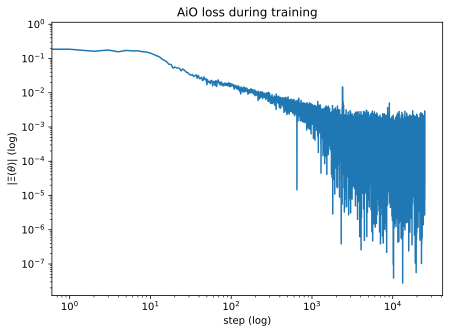

In [31]:
plt.figure()
plt.plot(np.abs(loss_history))
plt.yscale("log")
plt.xscale("log")
plt.title("AiO loss during training")
plt.xlabel("step (log)")
plt.ylabel(r"$|\Xi(\theta)|$ (log)")
plt.tight_layout()
plt.show()

The loss can be negative on individual draws (because of the product structure) — what matters is that $|\Xi|$ trends down.

## Inspecting the Trained Policy

We evaluate the policy at the trained parameters $\theta$ on a grid of $(y, w)$ values.

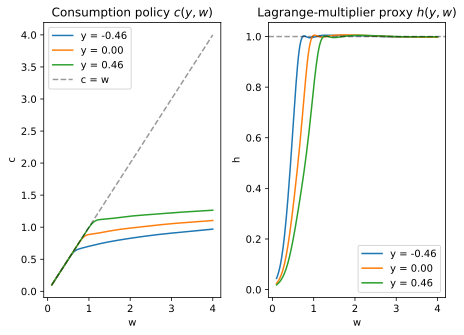

In [32]:
y_levels = jnp.array([-1 * sigma_e_y, 0.0, 1 * sigma_e_y])
w_grid = jnp.linspace(cfg.w_min, cfg.w_max * 0.5, 200)

fig, axes = plt.subplots(1, 2)
for y_val in y_levels:
    y_vec = jnp.full_like(w_grid, y_val)
    zeta_vec, h_vec = decision(params, y_vec, w_grid, cfg, sigma_e_y)
    axes[0].plot(w_grid, zeta_vec * w_grid, label=f"y = {float(y_val):.2f}")
    axes[1].plot(w_grid, h_vec, label=f"y = {float(y_val):.2f}")

axes[0].plot(w_grid, w_grid, "k--", alpha=0.4, label="c = w")
axes[0].set(title=r"Consumption policy $c(y, w)$", xlabel="w", ylabel="c")
axes[0].legend()

axes[1].axhline(1.0, color="k", linestyle="--", alpha=0.4)
axes[1].set(title=r"Lagrange-multiplier proxy $h(y, w)$", xlabel="w", ylabel="h")
axes[1].legend()
plt.tight_layout()
plt.show()

# Scaling Up: From the Toy Model to Krusell-Smith

## State Space for the KS Model

In the toy model the state was $(y, w) \in \mathbb{R}^2$.

In Krusell-Smith with $\ell$ agents, agent $i$'s relevant state space includes:

- own state: $(y_t^i, w_t^i)$
- aggregate shock: $z_t$
- distribution: $D_t = \{(y_t^j, w_t^j)\}_{j=1}^\ell$

Total dimension: $\mathbf{2\ell + 3}$. For $\ell = 1000$, that's a **2003-dimensional input** to the NN.

The classical KS algorithm dodges this by summarizing $D_t$ with $K_t$ alone and adding the forecasting rule. DL can take $D_t$ as input directly.

## KS Model: Equations

Following [@maliar_maliar_winant_2021], the economic block is:

$$
\begin{aligned}
\text{Idiosyncratic income}  &:\; \log y^i_{t+1} \;=\; \rho_y \log y^i_t + \sigma_y\, \varepsilon^i_{t+1}, \\
\text{Aggregate TFP}         &:\; \log z_{t+1}   \;=\; \rho_z \log z_t   + \sigma_z\, \varepsilon^z_{t+1}, \\
\text{Agent budget}          &:\; w^i_{t+1} \;=\; (1 + r_{t+1})\,(w^i_t - c^i_t) \;+\; W_{t+1}\, y^i_{t+1}, \\
\text{Borrowing}             &:\; w^i_t - c^i_t \;\ge\; 0.
\end{aligned}
$$

A representative firm with Cobb-Douglas technology $Y_t = z_t K_t^{\alpha} L_t^{1-\alpha}$ sets factor prices

$$
r_t \;=\; \alpha\, z_t \,(K_t/L_t)^{\alpha-1} - \delta,
\qquad
W_t \;=\; (1-\alpha)\, z_t \,(K_t/L_t)^{\alpha}.
$$

Aggregates are cross-sectional averages:

$$
K_t \;=\; \frac{1}{\ell}\sum_{i=1}^\ell w^i_t,
\qquad
L_t \;=\; \frac{1}{\ell}\sum_{i=1}^\ell y^i_t.
$$

This is what gives the **"$+3$"** in $2\ell + 3$: the aggregate state is $(z_t, K_t, L_t)$.

## Euler Equation in KS

When the borrowing constraint slacks ($w^i_t - c^i_t > 0$), the agent's first-order condition is

$$
u'(c^i_t) \;=\; \beta\, \mathbb{E}_t\!\left[\,(1 + r_{t+1})\, u'(c^i_{t+1})\,\right],
$$

where the expectation is taken over **two** independent shock sets:

- the cross-section of idiosyncratic shocks $\Sigma_{t+1} = \{\varepsilon^j_{t+1}\}_{j=1}^\ell$ (drives all $y^j_{t+1}$, hence $L_{t+1}$ and $W_{t+1}$),
- the aggregate shock $\varepsilon^z_{t+1}$ (drives $z_{t+1}$, hence $r_{t+1}$).

Compared to the toy model where $\bar r$ was an exogenous constant, $r_{t+1}$ here is a **function of the next-period distribution** $D_{t+1}$ — *that* is the hard part KS tries to summarize.

Defining the dimensionless ratio $h^i \;\equiv\; \beta\, \mathbb{E}_t\!\left[ (1 + r_{t+1})\, u'(c^i_{t+1})/u'(c^i_t) \right]$, the Euler-plus-constraint system collapses again to the FB equation $\Psi^{FB}(1 - \zeta^i,\; 1 - h^i) = 0$.

## What Stays the Same

- Two networks $\zeta(\cdot; \theta)$ and $h(\cdot; \theta)$, now functions of the $(2\ell + 3)$-dimensional state.
- Same FB equation for the constraint.
- Same dimensionless Euler residual $R_1, R_2$.
- Same AiO trick — but with **two sources of shocks**:
  - idiosyncratic $\varepsilon^i$ for each agent
  - aggregate $\varepsilon^z$ for $z$
- Two independent draws of *both* sets of shocks now define the AiO product.

## Loss Function for KS

Let $s^i_t = (y^i_t, w^i_t, z_t, D_t)$ be agent $i$'s full state. The two residuals are direct lifts of the toy-model definitions, with the constant $\bar r$ replaced by the KS-equilibrium gross return $1 + r_{t+1}$:

$$
\begin{aligned}
R_1^i\bigl(s^i_t,\; \varepsilon^{i\prime},\; \Sigma',\; \varepsilon^{z\prime}\bigr)
&\;\equiv\; \beta\,(1 + r_{t+1})\, \frac{u'(c^{i\prime})}{u'(c^i)} \;-\; h^i, \\
R_2^i\bigl(s^i_t\bigr)
&\;\equiv\; \Psi^{FB}\!\left(1 - \zeta^i,\; 1 - h^i\right).
\end{aligned}
$$

Both depend on the **next-period** distribution: $r_{t+1}$ requires $K_{t+1} = \tfrac{1}{\ell}\sum_j (w^j_t - c^j_t)$ and $W_{t+1}$ requires $L_{t+1} = \tfrac{1}{\ell}\sum_j y^j_{t+1}$.

## Loss Function for KS (cont.)

The AiO product needs **two independent draws** of the full shock set $(\Sigma_k, \sigma_k) = \bigl(\{\varepsilon^{j}_k\}_{j=1}^\ell,\; \varepsilon^{z}_k\bigr)$ to obtain an unbiased estimate of $\bigl(\mathbb{E}[R_1^i]\bigr)^2$:

$$
\begin{aligned}
\Xi(\theta) \;=\;& \mathbb{E}_{(D,\, z,\, \Sigma_1, \Sigma_2,\, \sigma_1, \sigma_2)}\Biggl[\,
\sum_{i=1}^\ell \Bigl(
\bigl( R_1^i \,\big|\, \Sigma_1, \sigma_1 \bigr) \cdot
\bigl( R_1^i \,\big|\, \Sigma_2, \sigma_2 \bigr) \\
&\hspace{5cm} +\; v \cdot R_2^i (D, z)^2
\Bigr)
\Biggr].
\end{aligned}
$$

Same structure as the toy model — just **richer state and richer shocks**.

## Algorithm: NN-KS Training Loop


**Initialize** $\theta$ for networks $\zeta(\cdot; \theta), h(\cdot; \theta)$; cross-section $D_0 = \{(y^i_0, w^i_0)\}_{i=1}^\ell$ (e.g. autarky steady state); aggregate state $z_0$.

**For** $n = 1, 2, \dots, N$ Adam steps:

1. **Simulate one period** using the current $\theta$: draw $\{\varepsilon^{i,\text{sim}}\}_i, \varepsilon^{z,\text{sim}}$ $\Rightarrow$ advance $(D_t, z_t) \to (D_{t+1}, z_{t+1})$.
2. **Draw two independent next-period shock sets** $(\Sigma_1, \sigma_1), (\Sigma_2, \sigma_2)$.
3. **Aggregate under each draw**: $K' = \tfrac{1}{\ell}\sum_j (w^j_t - c^j_t)$, $L'_k = \tfrac{1}{\ell}\sum_j y^{j\prime}_k$, then $r'_k, W'_k$ from the firm FOCs.
4. **Residuals** for each agent $i$: $R_1^i \big|_k$ for $k = 1, 2$, and $R_2^i$.
5. **AiO loss estimator**: $\;\widehat \Xi(\theta) = \tfrac{1}{\ell} \sum_{i=1}^\ell \Bigl[\,(R_1^i \big|_1) (R_1^i \big|_2) + v\, (R_2^i)^2\,\Bigr]$.
6. **Adam update**: $\theta \leftarrow \theta - \text{Adam-step}\bigl(\nabla_\theta \widehat \Xi\bigr)$.

**Output**: trained $\zeta(\cdot;\theta), h(\cdot;\theta)$ — evaluate on any state $(y, w, z, D)$ to get the policy.



## Where the Computation Goes

- **Forward simulation** of the cross-section every iteration: $O(\ell \cdot T_{sim})$ NN evaluations.
- **AiO loss evaluation**: $2 \cdot \ell$ NN evaluations per state in the batch.
- Both are perfectly vectorizable — GPU strongly recommended for $\ell \gtrsim 100$.

## Comparison: Classical KS vs NN-KS

| Aspect | Classical KS | NN-KS |
|---|---|---|
| Distribution treatment | Summarize $D$ by $K = \int k \, d\mu$ | Use full $D$ (or a learned summary) |
| Functional form | Log-linear forecasting rule | Deep network |
| Solver | Policy / value iteration on a grid | SGD on a residual loss |
| Convergence diagnostic | $R^2$ + DenHaan errors | Euler residual + accuracy check |
| Scaling with state dim | $O(G^d)$ | $O(d)$ in NN width |
| Approximation source | Approximate aggregation | Function-class capacity of the NN |

Different approximations, different failure modes. KS approximates the *information set*; NN approximates the *functional form*.

## When NN Wins

- States have rich cross-sectional structure that $K$ can't summarize (fat tails, kinks, MPC heterogeneity that matters in equilibrium).
- High-dimensional asset/portfolio choices.
- Aggregate state has many shocks beyond a single TFP.
- Studying transitions / impulse responses where global accuracy matters.

## When Classical KS Wins

- Approximate aggregation actually holds — there's nothing the NN can do that one regression can't.
- You need a quick, transparent answer with cheap parameter sensitivity.
- You can audit and explain every line; debugging NN training is a different sport.

## Further Reading — Discrete Time

- @maliar_maliar_winant_2021 — the lecture's main reference; toy model + KS with 1000 agents.
- @azinovic_gaegauf_scheidegger_2022 — Deep Equilibrium Nets.
- @maliar_maliar_2022_discrete — discrete labor choice via NN classification.
- @han_yang_e_2025_deepham — DeepHAM: generalized-moment representation of the distribution.
- @maliar_maliar_2023_hanc_hank — HANC / HANK without Krusell-Smith aggregation.
- @kahou_fernandez_villaverde_perla_sood_2024_symmetry — permutation-invariant networks for high-dim DP (the conceptual scaling-with-agents trick).

## Further Reading — Continuous Time / PDEs / Surveys

- @achdou_han_lasry_lions_moll_2022 — HACT framework (continuous-time HA macro).
- @han_jentzen_e_2018_deepbsde — deep BSDE for high-dimensional PDEs.
- @gu_lauriere_merkel_payne_2024 — master equation solver for continuous-time HA with aggregate shocks (KS-style globally).
- @payne_rebei_2024_deepsam — deep learning for search-and-matching (DeepSAM).
- @fernandez_villaverde_nuno_perla_2024 — recent survey on DL for quantitative economics.
- @fernandez_villaverde_2025_survey — pedagogical survey, "Deep Learning for Solving Economic Models".

## Takeaways

- DL methods reframe model solution as **stochastic optimization** on a residual loss.
- **Three losses** (lifetime utility, Euler residual, Bellman residual) cover the canonical equations of dynamic programming.
- The **AiO operator** collapses nested expectations into one — the key practical innovation.
- The toy model trains in **about two minutes** on CPU; the KS model with 1000 agents takes **hours** on CPU but is easily parallelised on GPU.
- Classical KS and NN-KS are complements — different approximations, different failure modes.

# References

::: {#refs}
:::